In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [5]:
data = sns.load_dataset('diamonds')

## Basic Info about the data

In [8]:
data.head(10)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
6,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
7,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
8,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
9,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


In [10]:
data.shape

(53940, 10)

In [12]:
data.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='object')

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


#### The data contains 3 categorical columns and 7 numerical columns

## Statistical Summary

In [18]:
data.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


### Checking for Null Values

In [21]:
data.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

#### The dataset does not contain any null values.

### Checking for Duplicate Values

In [25]:
data.duplicated().sum()

146

In [27]:
data[data.duplicated()]

,carat,cut,color,clarity,depth,table,price,x,y,z
1005,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
1006,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
1007,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
1008,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
2025,1.52,Good,E,I1,57.3,58.0,3105,7.53,7.42,4.28
...,...,...,...,...,...,...,...,...,...,...
47969,0.52,Ideal,D,VS2,61.8,55.0,1919,5.19,5.16,3.20
49326,0.51,Ideal,F,VVS2,61.2,56.0,2093,5.17,5.19,3.17
49557,0.71,Good,F,SI2,64.1,60.0,2130,0.00,0.00,0.00
50079,0.51,Ideal,F,VVS2,61.2,56.0,2203,5.19,5.17,3.17


#### The dataset contains 146 duplicated rows.

## Dropping duplicates

In [31]:
data.drop_duplicates(inplace=True)

In [33]:
data.duplicated().sum()

0

## Detecting Outliers

<Axes: ylabel='carat'>

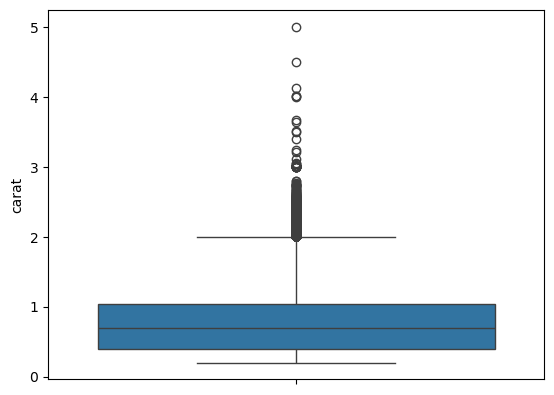

In [36]:
sns.boxplot(y='carat', data=data)

In [38]:
data.carat.describe()

count    53794.00000
mean         0.79778
std          0.47339
min          0.20000
25%          0.40000
50%          0.70000
75%          1.04000
max          5.01000
Name: carat, dtype: float64

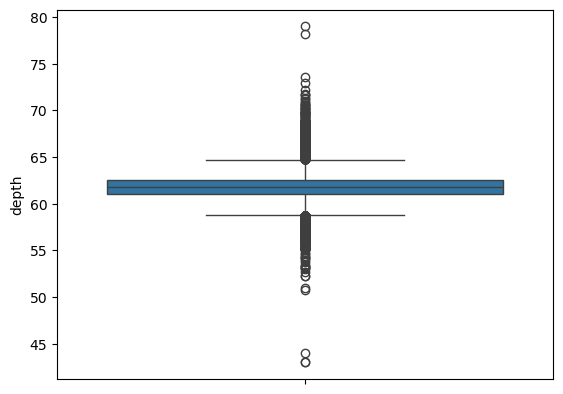

In [40]:
sns.boxplot(y='depth',data=data)
plt.show()

In [42]:
data.depth.describe()

count    53794.000000
mean        61.748080
std          1.429909
min         43.000000
25%         61.000000
50%         61.800000
75%         62.500000
max         79.000000
Name: depth, dtype: float64

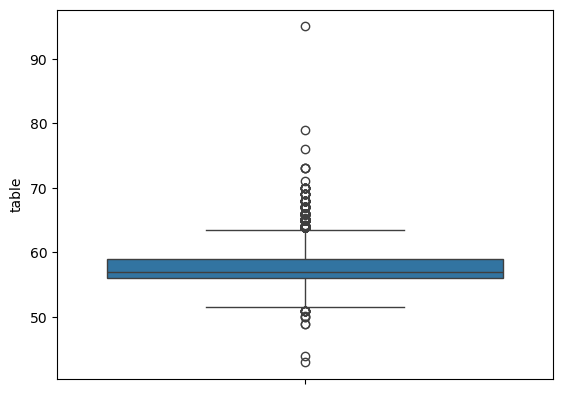

In [44]:
sns.boxplot(y='table',data=data)
plt.show()

In [46]:
data.table.describe()

count    53794.000000
mean        57.458109
std          2.233679
min         43.000000
25%         56.000000
50%         57.000000
75%         59.000000
max         95.000000
Name: table, dtype: float64

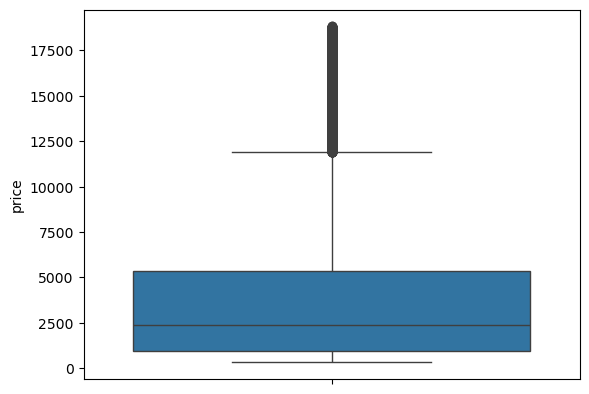

In [48]:
sns.boxplot(y='price',data=data)
plt.show()

In [50]:
data.price.describe()

count    53794.000000
mean      3933.065082
std       3988.114460
min        326.000000
25%        951.000000
50%       2401.000000
75%       5326.750000
max      18823.000000
Name: price, dtype: float64

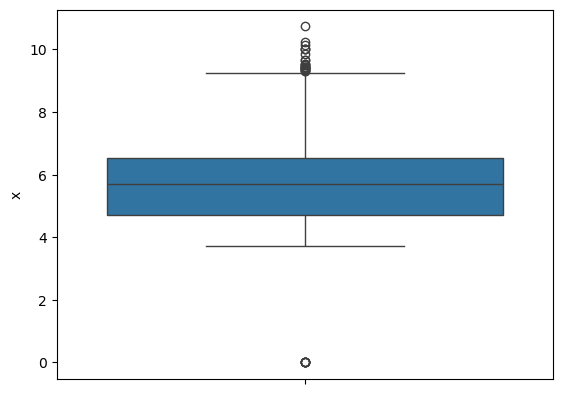

In [52]:
sns.boxplot(y='x',data=data)
plt.show()

In [54]:
data.x.describe()

count    53794.000000
mean         5.731214
std          1.120695
min          0.000000
25%          4.710000
50%          5.700000
75%          6.540000
max         10.740000
Name: x, dtype: float64

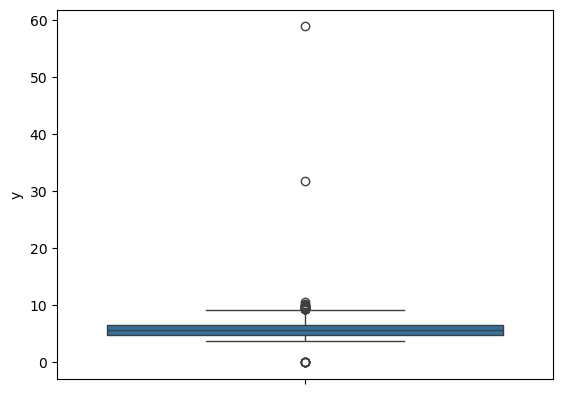

In [56]:
sns.boxplot(y='y',data=data)
plt.show()

In [58]:
data.y.describe()

count    53794.000000
mean         5.734653
std          1.141209
min          0.000000
25%          4.720000
50%          5.710000
75%          6.540000
max         58.900000
Name: y, dtype: float64

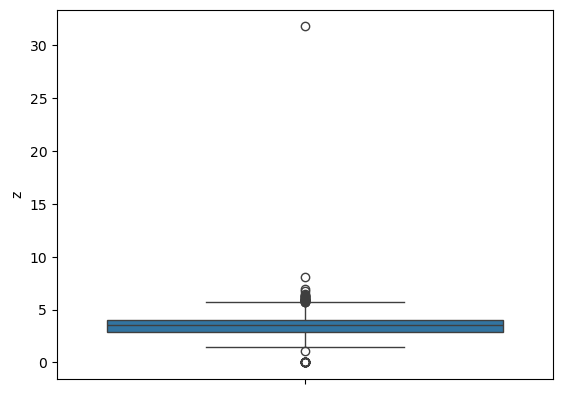

In [60]:
sns.boxplot(y='z',data=data)
plt.show()

In [62]:
data.z.describe()

count    53794.000000
mean         3.538714
std          0.705037
min          0.000000
25%          2.910000
50%          3.530000
75%          4.030000
max         31.800000
Name: z, dtype: float64

- All the numeric columns in the diamonds dataset contain outliers
- x, y and z columns have less outliers
- price column has the maximum outliers

## Removing Outliers using IQR Method

In [66]:
# User Defined function to remove outliers
def outlier(dt):
    Q1=dt.quantile(0.25)
    Q3=dt.quantile(0.75)

    IQR = Q3-Q1
    Upper_Bound = Q3 + 1.5*IQR
    Lower_Bound = Q1 - 1.5*IQR
    
    return dt.clip(Upper_Bound,Lower_Bound)

In [68]:
data['Carat'] = outlier(data.carat)

In [70]:
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,Carat
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,0.23
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,0.21
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,0.23
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,0.29
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,0.31


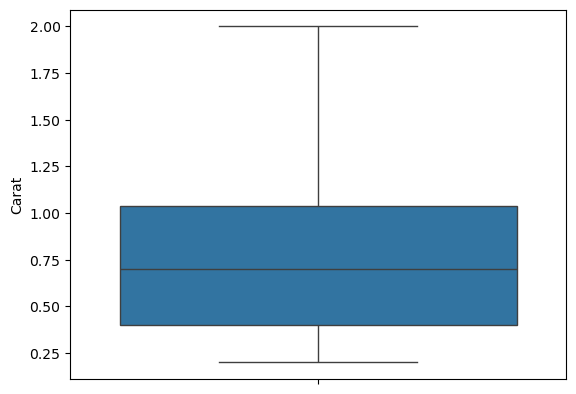

In [72]:
sns.boxplot(y='Carat',data=data)
plt.show()

In [74]:
data['Depth'] = outlier(data.depth)

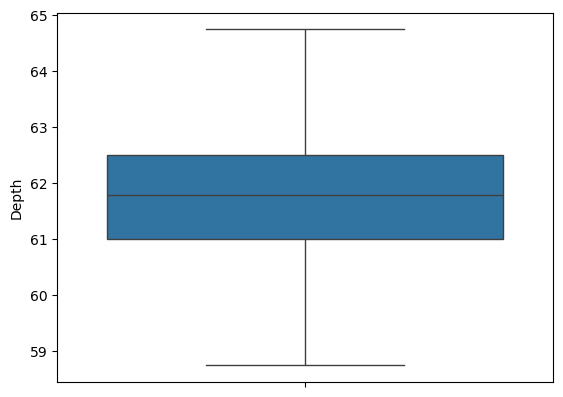

In [76]:
sns.boxplot(y='Depth',data=data)
plt.show()

In [78]:
data['Table'] = outlier(data.table)

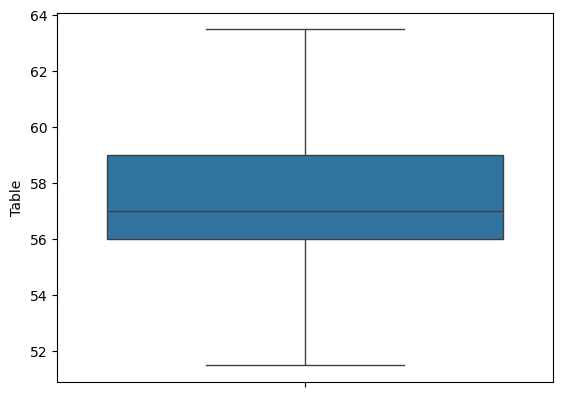

In [80]:
sns.boxplot(y='Table',data=data)
plt.show()

In [82]:
data['Price']= outlier(data.price)

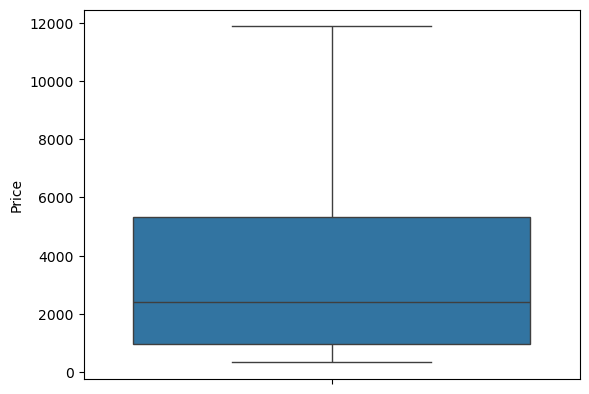

In [84]:
sns.boxplot(y='Price',data=data)
plt.show()

In [86]:
data['X'] = outlier(data.x)

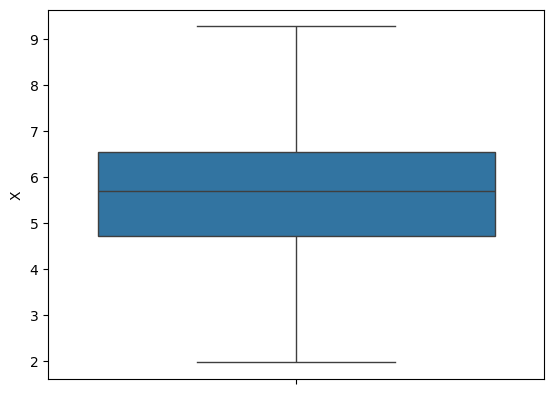

In [88]:
sns.boxplot(y='X',data=data)
plt.show()

In [90]:
data['Y']= outlier(data.y)

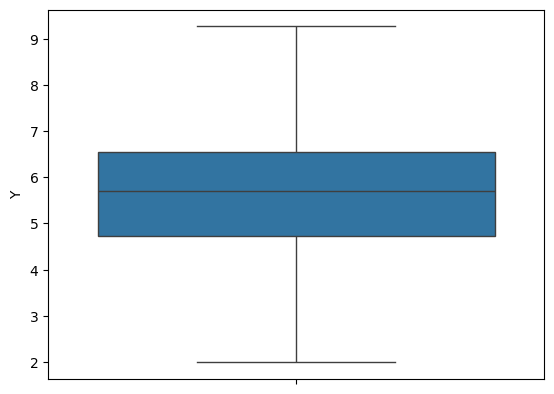

In [92]:
sns.boxplot(y='Y',data=data)
plt.show()

In [94]:
data['Z'] = outlier(data.z)

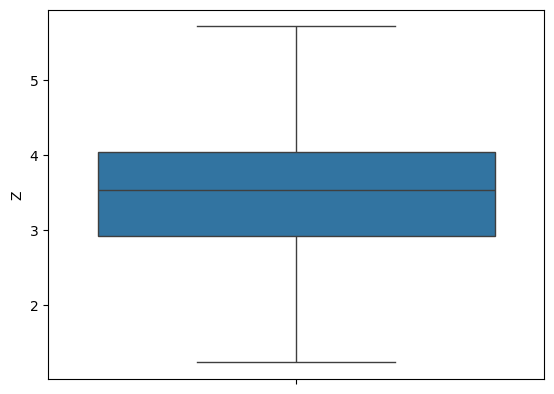

In [96]:
sns.boxplot(y='Z',data=data)
plt.show()

In [98]:
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,Carat,Depth,Table,Price,X,Y,Z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,0.23,61.50,55.0,326.0,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,0.21,59.80,61.0,326.0,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,0.23,58.75,63.5,327.0,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,0.29,62.40,58.0,334.0,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,0.31,63.30,58.0,335.0,4.34,4.35,2.75


# Analysis

## Average Price according to the cut

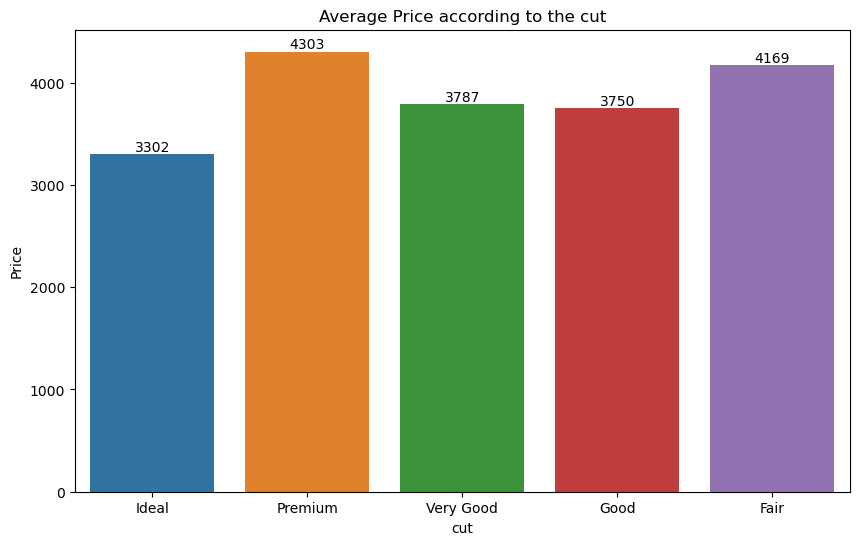

In [102]:
plt.figure(figsize = (10,6),dpi=100)
ax=sns.barplot(x='cut',y='Price',data=data,errorbar=('ci',False),hue='cut')
for i in ax.containers:
    ax.bar_label(i,fmt='%.f')
plt.title('Average Price according to the cut')
plt.show()

## Minimum Price according to the cut

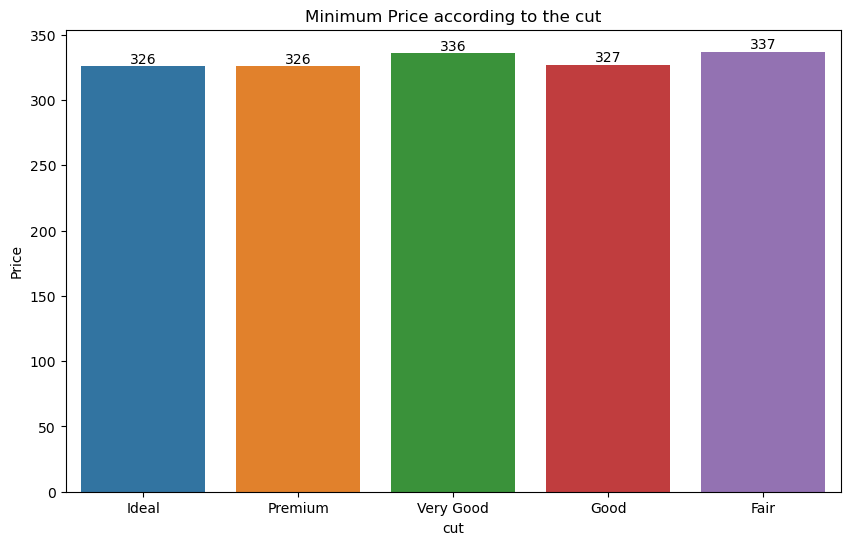

In [105]:
plt.figure(figsize = (10,6),dpi=100)
ax=sns.barplot(x='cut',y='Price',data=data,errorbar=('ci',False),hue='cut',estimator=np.min)
for i in ax.containers:
    ax.bar_label(i,fmt='%.f')
plt.title('Minimum Price according to the cut')
plt.show()

## Ratio of cut

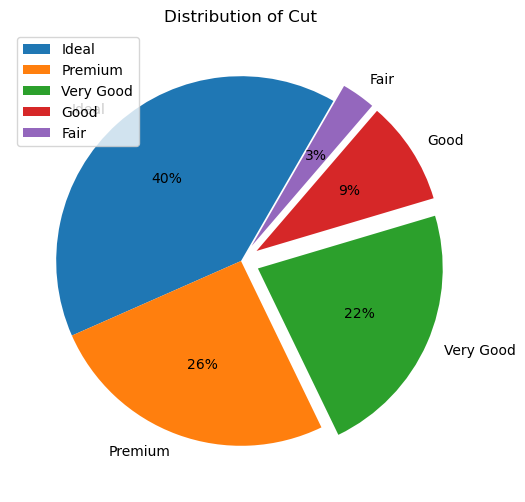

In [108]:
plt.figure(figsize=(10,6),dpi=100)
explode=[0,0,0.1,0.1,0.1]
plt.pie(data.cut.value_counts(),labels=data.cut.value_counts().index,autopct='%.f%%',startangle=60,explode=explode)
plt.title('Distribution of Cut')
plt.legend()
plt.show()

## Ratio of clarity

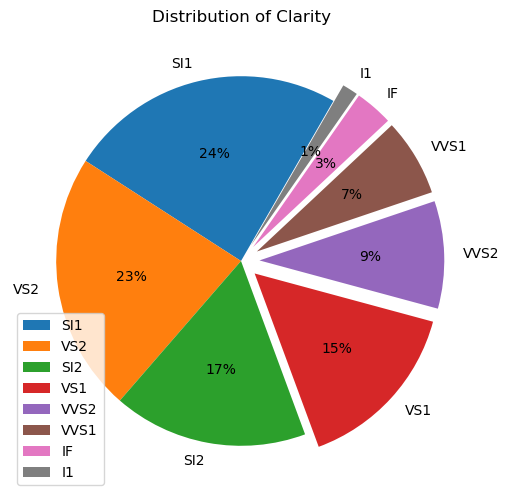

In [111]:
plt.figure(figsize=(10,6),dpi=100)
explode = [0,0,0,0.1,0.1,0.1,0.1,0.1]
plt.pie(data.clarity.value_counts(),labels=data.clarity.value_counts().index,autopct='%.f%%',startangle=60,explode=explode,shadow=False)
plt.title('Distribution of Clarity')
plt.legend()
plt.show()

## Observations according to color

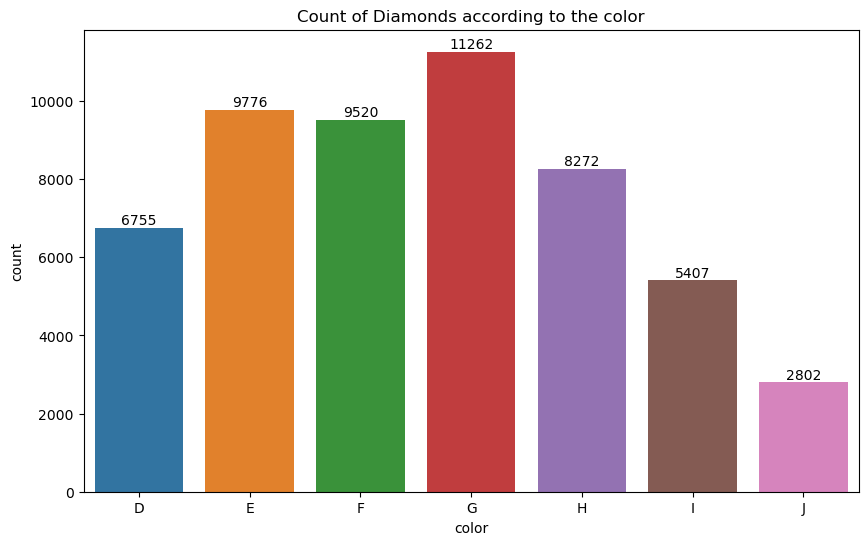

In [114]:
plt.figure(figsize=(10,6),dpi=100)
ax=sns.countplot(x='color',data=data,hue='color')

for i in ax.containers:
    ax.bar_label(i)
plt.title("Count of Diamonds according to the color")
plt.show()          

## Relationship between Depth and Price on the basis of cut

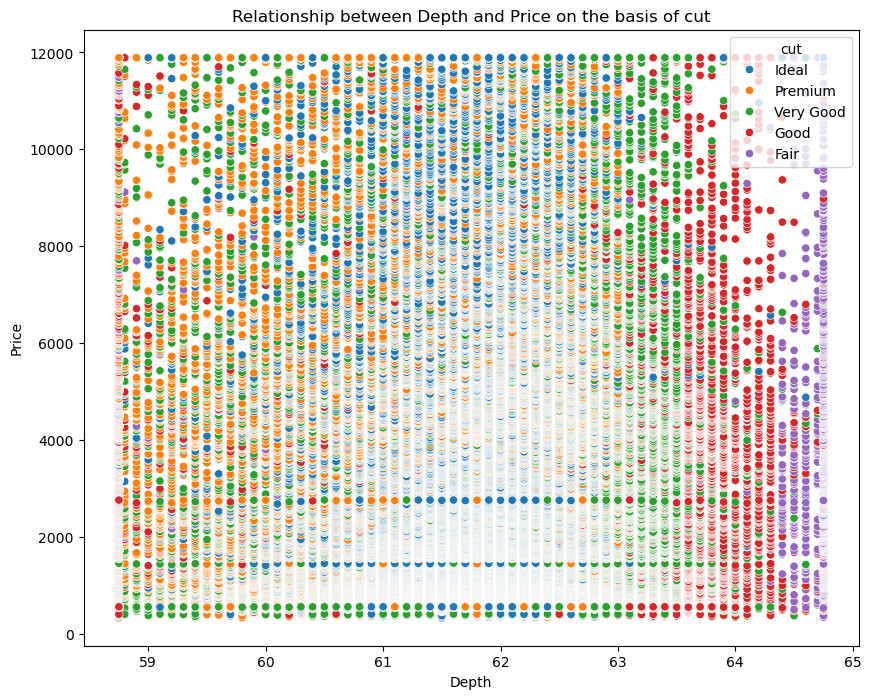

In [117]:
plt.figure(figsize=(10,8),dpi=100)
sns.scatterplot(x='Depth',y='Price',hue='cut',data=data)
plt.xlabel('Depth')
plt.ylabel('Price')
plt.title('Relationship between Depth and Price on the basis of cut')
plt.show()

## Correlation

In [119]:
selected_columns = ['Carat','Depth','Table','Price','X','Y','Z']
numeric_data = data[selected_columns]

In [120]:
numeric_data.head()

,Carat,Depth,Table,Price,X,Y,Z
0,0.23,61.50,55.0,326.0,3.95,3.98,2.43
1,0.21,59.80,61.0,326.0,3.89,3.84,2.31
2,0.23,58.75,63.5,327.0,4.05,4.07,2.31
3,0.29,62.40,58.0,334.0,4.20,4.23,2.63
4,0.31,63.30,58.0,335.0,4.34,4.35,2.75


In [122]:
numeric_data.corr()

,Carat,Depth,Table,Price,X,Y,Z
Carat,1.000000,0.021519,0.186775,0.936545,0.981959,0.981231,0.977588
Depth,0.021519,1.000000,-0.299939,-0.009098,-0.029115,-0.031816,0.089743
Table,0.186775,-0.299939,1.000000,0.136167,0.197725,0.191757,0.157434
Price,0.936545,-0.009098,0.136167,1.000000,0.911937,0.913459,0.905015
X,0.981959,-0.029115,0.197725,0.911937,1.000000,0.998357,0.988258
Y,0.981231,-0.031816,0.191757,0.913459,0.998357,1.000000,0.987882
Z,0.977588,0.089743,0.157434,0.905015,0.988258,0.987882,1.000000


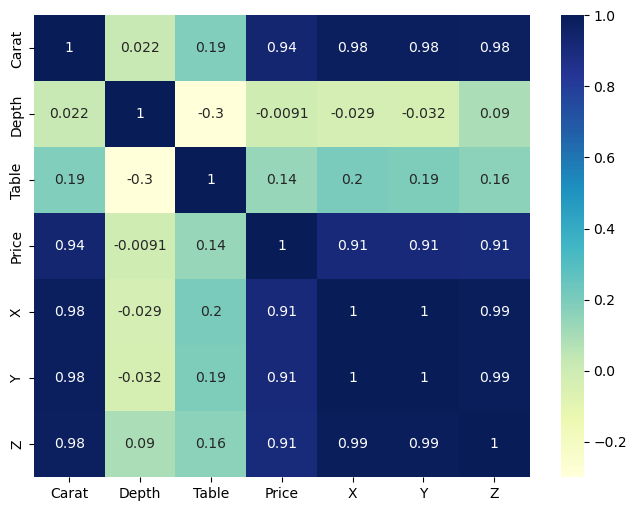

In [124]:
plt.figure(figsize=(8,6),dpi=100)
sns.heatmap(numeric_data.corr(),annot=True,cmap="YlGnBu")
plt.show()